In [1]:
# NT Crime Data — Exploratory Data Analysis
# Author: Quoc Chien Kieu (Nolan)
# Dataset: NT Police Recorded Offences 2023-2025

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Load data
df = pd.read_csv('nt_crime_statistics_jan_2025.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (3534, 10)

Columns: ['As At', 'Year', 'Month number', 'Offence category', 'Offence type', 'Alcohol involvement', 'DV involvement', 'Reporting region', 'Statistical Area 2', 'Number of offences']

First 5 rows:


,As At,Year,Month number,Offence category,Offence type,Alcohol involvement,DV involvement,Reporting region,Statistical Area 2,Number of offences
0,3/03/2025,2023,12,Abduction - harassment and other offences agai...,Deprivation of liberty /false imprisonment,-,-,Darwin,NaN,1
1,3/03/2025,2023,12,Abduction - harassment and other offences agai...,Deprivation of liberty /false imprisonment,-,-,NT Balance,Yuendumu - Anmatjere,1
2,3/03/2025,2023,12,Abduction - harassment and other offences agai...,Harassment and private nuisance,-,-,Alice Springs,NaN,1
3,3/03/2025,2023,12,Abduction - harassment and other offences agai...,Harassment and private nuisance,-,-,Darwin,NaN,3
4,3/03/2025,2023,12,Abduction - harassment and other offences agai...,Harassment and private nuisance,-,-,NT Balance,Barkly,1


In [2]:
# Rename columns để dễ dùng
df.columns = ['As_At', 'Year', 'Month_number', 'Offence_category', 
              'Offence_type', 'Alcohol_involvement', 'DV_involvement', 
              'Reporting_region', 'Statistical_Area_2', 'Number_of_offences']

print("=== DATA QUALITY CHECK ===")
print(f"Total records: {len(df):,}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nYear range: {df['Year'].min()} - {df['Year'].max()}")
print(f"\nUnique regions: {df['Reporting_region'].unique()}")

=== DATA QUALITY CHECK ===
Total records: 3,534

Missing values:
As_At                     0
Year                      0
Month_number              0
Offence_category          0
Offence_type              0
Alcohol_involvement       0
DV_involvement            0
Reporting_region          0
Statistical_Area_2     1263
Number_of_offences        0
dtype: int64

Year range: 2023 - 2025

Unique regions: ['Darwin' 'NT Balance' 'Alice Springs' 'Palmerston' 'Katherine'
 'Nhulunbuy' 'Tennant Creek']


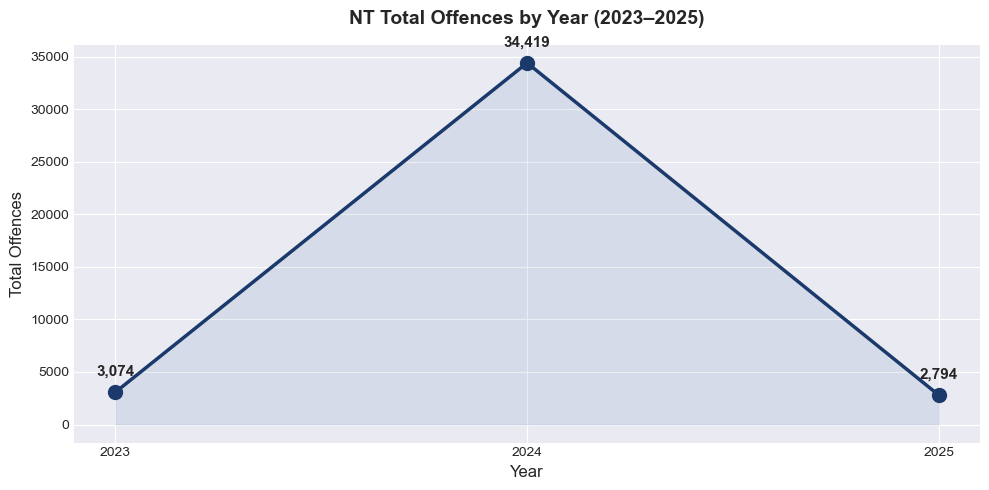

✅ Chart 1 saved!


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

yearly = df.groupby('Year')['Number_of_offences'].sum().reset_index()

ax.plot(yearly['Year'], yearly['Number_of_offences'], 
        marker='o', linewidth=2.5, markersize=10, color='#1B3A6B')
ax.fill_between(yearly['Year'], yearly['Number_of_offences'], 
                alpha=0.1, color='#2E5FA3')

for _, row in yearly.iterrows():
    ax.annotate(f"{int(row['Number_of_offences']):,}", 
                (row['Year'], row['Number_of_offences']),
                textcoords="offset points", xytext=(0,12), 
                ha='center', fontsize=11, fontweight='bold')

ax.set_title('NT Total Offences by Year (2023–2025)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Offences', fontsize=12)
ax.set_xticks([2023, 2024, 2025])
plt.tight_layout()
plt.savefig('chart1_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

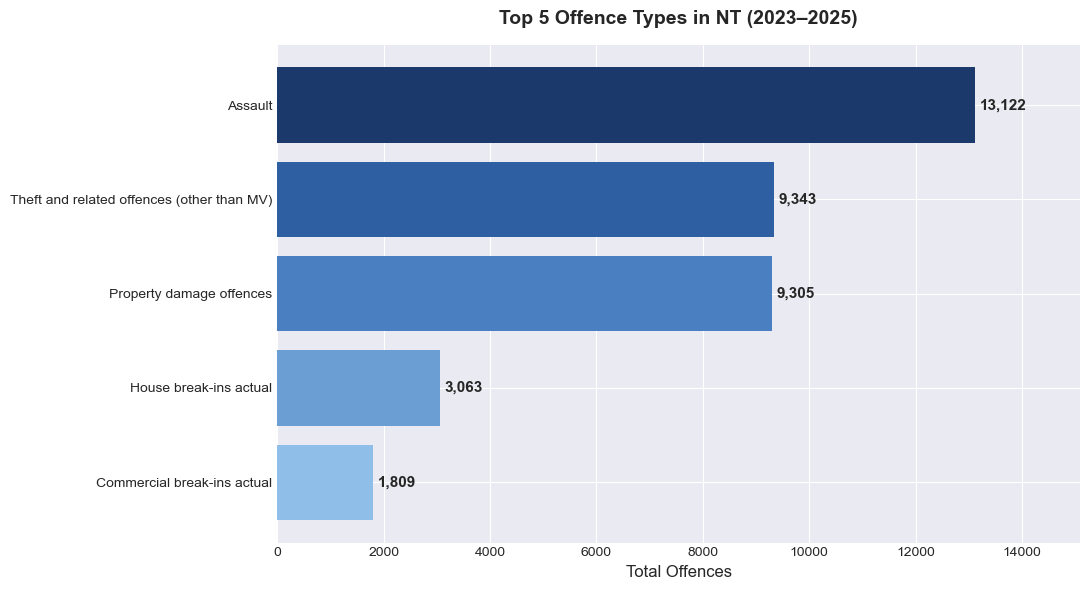

✅ Chart 2 saved!


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

top5 = df.groupby('Offence_type')['Number_of_offences']\
         .sum().nlargest(5).sort_values(ascending=True).reset_index()

colors = ['#8FBFE8','#6B9FD4','#4A7FC1','#2E5FA3','#1B3A6B']
bars = ax.barh(top5['Offence_type'], top5['Number_of_offences'], color=colors)

for bar, val in zip(bars, top5['Number_of_offences']):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Top 5 Offence Types in NT (2023–2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Offences', fontsize=12)
ax.set_xlim(0, top5['Number_of_offences'].max() * 1.15)
plt.tight_layout()
plt.savefig('chart2_top5_offences.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

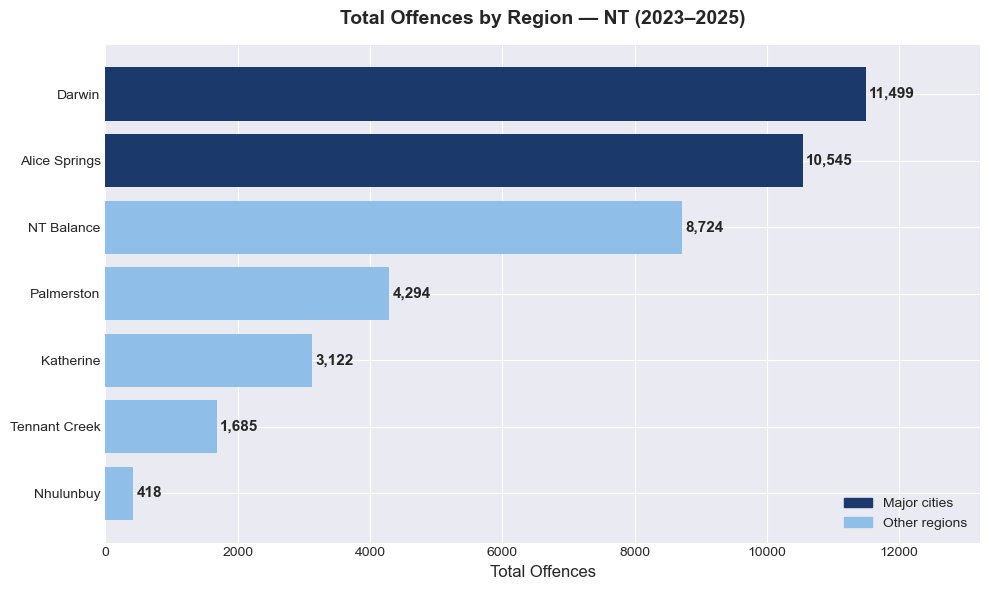

✅ Chart 3 saved!


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

regional = df.groupby('Reporting_region')['Number_of_offences']\
             .sum().sort_values(ascending=True).reset_index()

colors = ['#8FBFE8' if r not in ['Darwin', 'Alice Springs'] 
          else '#1B3A6B' for r in regional['Reporting_region']]

bars = ax.barh(regional['Reporting_region'], 
               regional['Number_of_offences'], color=colors)

for bar, val in zip(bars, regional['Number_of_offences']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Total Offences by Region — NT (2023–2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Offences', fontsize=12)
ax.set_xlim(0, regional['Number_of_offences'].max() * 1.15)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#1B3A6B', label='Major cities'),
          Patch(color='#8FBFE8', label='Other regions')]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('chart3_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

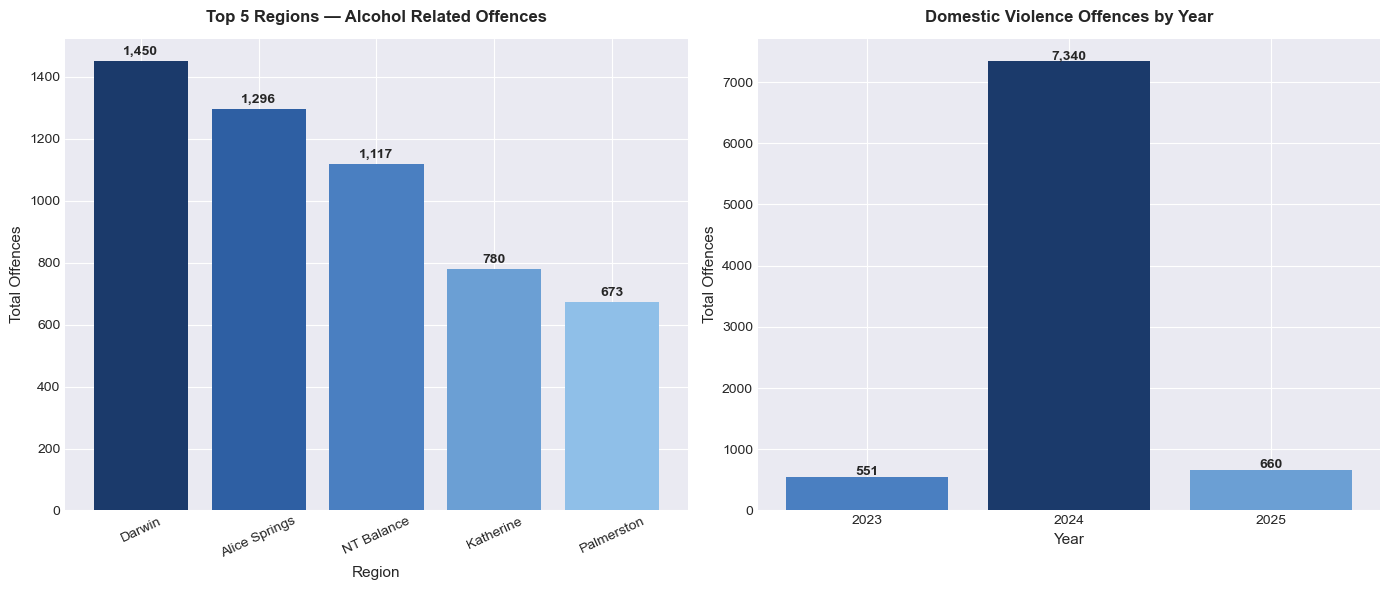

✅ Chart 4 saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 4a — Alcohol by Region (Top 5)
alcohol = df[df['Alcohol_involvement'] == 'Yes']\
            .groupby('Reporting_region')['Number_of_offences']\
            .sum().sort_values(ascending=False).head(5)

bars = axes[0].bar(alcohol.index, alcohol.values,
                   color=['#1B3A6B','#2E5FA3','#4A7FC1','#6B9FD4','#8FBFE8'])
axes[0].set_title('Top 5 Regions — Alcohol Related Offences',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Region', fontsize=11)
axes[0].set_ylabel('Total Offences', fontsize=11)
axes[0].tick_params(axis='x', rotation=25)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=10, fontweight='bold')

# Chart 4b — DV by Year
dv = df[df['DV_involvement'] == 'Yes']\
       .groupby('Year')['Number_of_offences'].sum()

bars2 = axes[1].bar(dv.index, dv.values,
                    color=['#4A7FC1','#1B3A6B','#6B9FD4'])
axes[1].set_title('Domestic Violence Offences by Year',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Total Offences', fontsize=11)
axes[1].set_xticks([2023, 2024, 2025])
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_alcohol_dv.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

In [7]:
print("=" * 55)
print("   NT CRIME DATA — KEY INSIGHTS SUMMARY")
print("=" * 55)

total = df['Number_of_offences'].sum()
top_offence = df.groupby('Offence_type')['Number_of_offences']\
                .sum().idxmax()
top_region = df.groupby('Reporting_region')['Number_of_offences']\
               .sum().idxmax()
alcohol_pct = df[df['Alcohol_involvement']=='Yes']['Number_of_offences']\
                .sum() / total * 100
dv_2023 = df[(df['Year']==2023) & (df['DV_involvement']=='Yes')]\
            ['Number_of_offences'].sum()
dv_2024 = df[(df['Year']==2024) & (df['DV_involvement']=='Yes')]\
            ['Number_of_offences'].sum()

print(f"\n📊 Total offences (2023-2025) : {total:,}")
print(f"👊 #1 Offence type            : {top_offence}")
print(f"📍 Highest crime region       : {top_region}")
print(f"🍺 Alcohol-related            : {alcohol_pct:.1f}% of all offences")
print(f"🏠 DV offences 2023           : {dv_2023:,}")
print(f"🏠 DV offences 2024           : {dv_2024:,}")
print(f"📈 DV increase 2023→2024      : {dv_2024/dv_2023:.1f}x")
print(f"\n⭐ Alice Springs crime despite")
print(f"   being 3x smaller than Darwin!")
print("\n" + "=" * 55)
print("✅ EDA Complete — 4 charts saved!")

   NT CRIME DATA — KEY INSIGHTS SUMMARY

📊 Total offences (2023-2025) : 40,287
👊 #1 Offence type            : Assault
📍 Highest crime region       : Darwin
🍺 Alcohol-related            : 14.4% of all offences
🏠 DV offences 2023           : 551
🏠 DV offences 2024           : 7,340
📈 DV increase 2023→2024      : 13.3x

⭐ Alice Springs crime despite
   being 3x smaller than Darwin!

✅ EDA Complete — 4 charts saved!
